# Assignment 8 

In [1]:
# Import our dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

cluster_data = pd.read_csv('clustering_synthetic_dataset.csv')

# Explore the dataset
print(cluster_data.head())

         f1        f2
0  0.494261  1.451067
1 -1.428081 -0.837064
2  0.338559  1.038759
3  0.119001 -1.053976
4  1.122425  1.774937


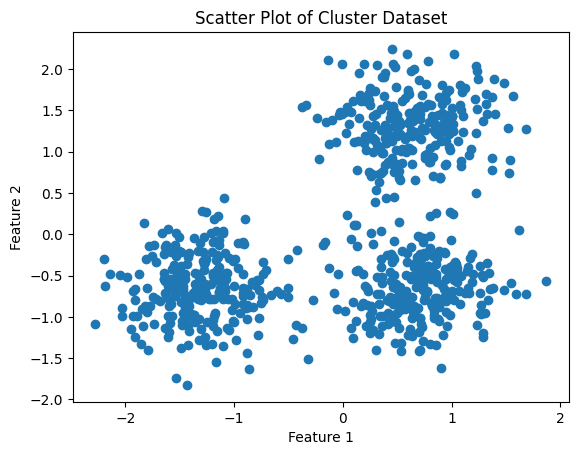

In [2]:
# scatter plot of the dataset
plt.scatter(cluster_data['f1'], cluster_data['f2'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Cluster Dataset')
plt.show()


Clearly, we can see that there are 3 different clusteres. So I will use 3.

## 2. Feature Ranges
- Species 1 has feature 1 in the range of -3 to -0.25 and feature 2 in the range of -2 to 0.5
- Species 2 has feature 1 in the range of -0.25 to 2 and feature 2 in the range of -1.75 to 0.25
- Species 3 has feature 1 in the range of -0.5 to 1.75 and feature 2 in the range of 0.25 to 3

## 3. Use K-means to find anomalies

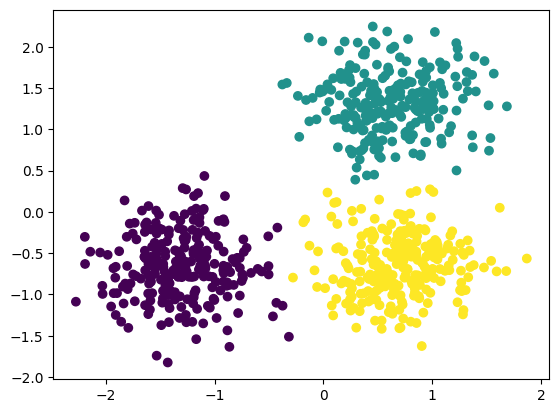

In [3]:
# k-means clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(cluster_data)

# plot the clusters
plt.scatter(cluster_data['f1'], cluster_data['f2'], c=kmeans.labels_)
plt.show()

Per-cluster thresholds:
cluster
0    1.110212
1    1.046264
2    1.061663


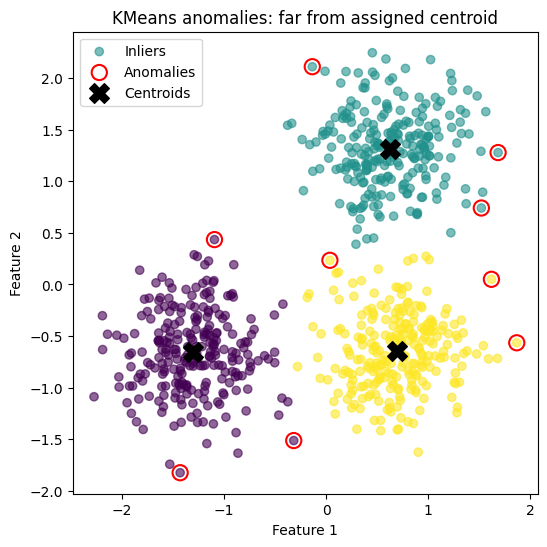

In [4]:
# KMeans anomaly detection: per-cluster percentile on distance to centroid

distances_to_all_centroids = kmeans.transform(cluster_data)
assigned_dist = distances_to_all_centroids[np.arange(len(cluster_data)), kmeans.labels_]

results_df = cluster_data.copy()
results_df['cluster'] = kmeans.labels_
results_df['dist_to_centroid'] = assigned_dist

# find anomalies using per cluster percentile threshold 
p = 0.99  
cluster_thresholds = results_df.groupby('cluster')['dist_to_centroid'].quantile(p)
results_df['threshold'] = results_df['cluster'].map(cluster_thresholds)
results_df['is_anomaly'] = results_df['dist_to_centroid'] > results_df['threshold']

print("Per-cluster thresholds:")
print(cluster_thresholds.to_string())

plt.figure(figsize=(6, 6))
plt.scatter(results_df['f1'], results_df['f2'], c=results_df['cluster'], cmap='viridis', alpha=0.6, label='Inliers')
plt.scatter(results_df.loc[results_df['is_anomaly'], 'f1'], results_df.loc[results_df['is_anomaly'], 'f2'],
            edgecolor='red', facecolor='none', s=120, linewidths=1.5, label='Anomalies')

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans anomalies: far from assigned centroid')
plt.legend()
plt.show()

## 4. Anomalies using DBSCAN

DBSCAN anomalies: 18 of 750


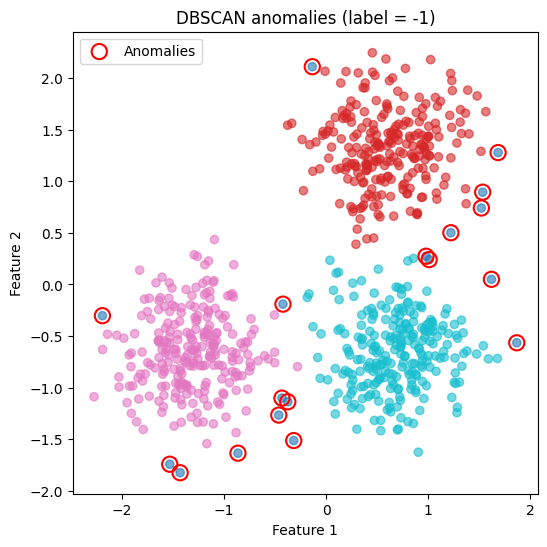

In [5]:
# DBSCAN anomalies (points labeled -1)
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(cluster_data)
db = DBSCAN(eps=0.3, min_samples=10).fit(X_scaled)
labels_db = db.labels_
anomaly_db = labels_db == -1

results_db = cluster_data.copy()
results_db['dbscan_label'] = labels_db
results_db['is_anomaly'] = anomaly_db

print(f"DBSCAN anomalies: {int(anomaly_db.sum())} of {len(results_db)}")

plt.figure(figsize=(6, 6))
plt.scatter(results_db['f1'], results_db['f2'], c=results_db['dbscan_label'], cmap='tab10', alpha=0.6)
plt.scatter(results_db.loc[anomaly_db, 'f1'], results_db.loc[anomaly_db, 'f2'],
            edgecolor='red', facecolor='none', s=120, linewidths=1.5, label='Anomalies')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN anomalies (label = -1)')
plt.legend()
plt.show()


## 5. Remove points found by DBSCAN and Create a Decision Tree Classifier



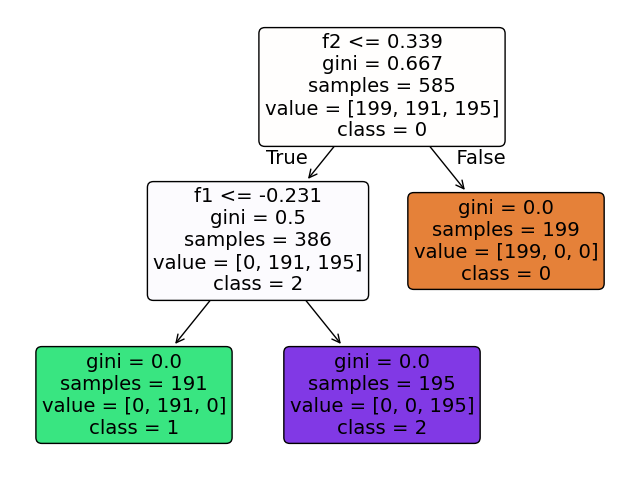

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

mask_inliers = ~anomaly_db
X_inliers = cluster_data.loc[mask_inliers, ['f1', 'f2']].values
y_inliers = labels_db[mask_inliers]

X_train, X_test, y_train, y_test = train_test_split(X_inliers, y_inliers, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)

plt.figure(figsize=(8, 6))
plot_tree(
    clf,
    feature_names=['f1', 'f2'],
    class_names=[str(c) for c in sorted(np.unique(y_inliers))],
    filled=True,
    rounded=True,
)
plt.show()


In [7]:
# get a score report for the decision tree
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
db_classfication_report = classification_report(y_test, y_pred)
print(db_classfication_report)


              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.98      0.99        53
           2       1.00      1.00      1.00        50

    accuracy                           0.99       147
   macro avg       0.99      0.99      0.99       147
weighted avg       0.99      0.99      0.99       147



In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_raw = cluster_data[['f1', 'f2']].values
y_raw = labels_db

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

clf_raw = DecisionTreeClassifier(max_depth=2)
clf_raw.fit(X_train_raw, y_train_raw)

y_pred_raw = clf_raw.predict(X_test_raw)
raw_classification_report = classification_report(y_test_raw, y_pred_raw, digits=3)
print("Decision tree on raw data:")
print(raw_classification_report)


Decision tree on raw data:
              precision    recall  f1-score   support

          -1      0.000     0.000     0.000         4
           0      0.980     1.000     0.990        48
           1      1.000     0.959     0.979        49
           2      0.925     1.000     0.961        49

    accuracy                          0.960       150
   macro avg      0.726     0.740     0.732       150
weighted avg      0.942     0.960     0.950       150



After cleaning with DBSCAN, overall accuracy improves from 0.96 to 0.99, and the macro and weighted F1 scores rise from 0.732 and 0.950 to 0.99 and 0.99. The raw model is penalized by the outlier class −1, which has zero precision, recall, and F1. Once those anomalies are removed, class performance becomes both higher and more balanced. Notably, class 2 precision increases from 0.925 to 1.00 and class 1 recall from 0.959 to 0.98, with all classes around 0.99 to 1.00 on the cleaned set. Test support decreases slightly from 150 to 147 because of the outlier removal, producing cleaner boundaries and near‑perfect, more reliable classification.